In [1]:
from libraries import *

In [2]:
# gp.setParam("OutputFlag", 1) # Disables Gurobi logs (Affects all models created afterward)

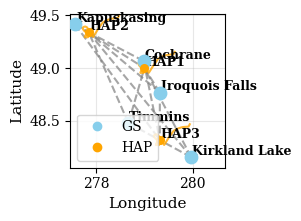

⏱️ Calculating K_MAX from t=0 to t=86399 (86400 time steps)
🧩 Total tasks: 2592000 (30 links × 86400 timesteps)


Computing key rates:  48%|███████████████████████                         | 1243731/2592000 [6:10:23<8:39:01, 43.29it/s]

In [ ]:
gnodes, hnodes, links, demands = init_setup_real()

In [ ]:
# solution = offline(gnodes, hnodes, links, demands)
# plot_solution(solution)

In [ ]:
# history = {}
# for t in range(5):
#     solution, history = online(history, gss, haps, links, demands, t)
#     print_solution(solution)
#     #plot_solution(solution)

In [ ]:
# # "FREE", "FIXED", "INIT"
# solution = planning("FIXED", gnodes, hnodes, links)
# # print_solution(solution)
# plot_solution(solution)

In [ ]:
# plot_key_rate_stratotegic(1, 0, 0, 0)

In [ ]:
# plot_transmittance_stratotegic_real()

In [ ]:
# plot_loss_distance(1, 0, 0, 0)

In [ ]:
# plot_loss_fog()

In [ ]:
# plot_loss_rain()

In [ ]:
# from balloon_qnet.QEuropeFunctions import *
# import balloon_qnet.transmittance as transmittance
# from balloon_qnet.free_space_losses import DownlinkChannel, compute_channel_length, CachedChannel
# import multiprocessing as mlp
# import os
# import functools as fnct

# # Parameters
# wavelength = 1550e-9
# zenith_angle = 0
# ground_station_alt = 0.020 #Altitude of the receiving telescope
# obs_ratio_ground = 0.3 #Obscuration ratio of the receiving telescope same
# Cn0 = 9.6*10**(-14) #Reference index of refraction structure constant at ground level
# u_rms = 10 #Wind speed
# pointing_error = 1e-6 #Pointing error variance
# Qonnector_meas_succ = 0.85 #Detector efficiency at the receiver
# tracking_efficiency = 0.8 # Tracking efficiency
# rx_aperture_ground = 0.3 #Aperture of the receiving telescope 
# W0 = 0.1 #Initial Beam Waist 

# h_balloons = 18 #Altitude range of the balloon
# n_max_ground = [2,3,4,5,6,7,8,9,10] #Maximum radial index of correction of AO system 

# simtime = 500000 #Simulation time

# RE = 6371 # Earth's radius [km]
# c = 299792458 

# def compute_channel_length(ground_station_alt, aerial_platform_alt, zenith_angle):
#     """Compute channel length that corresponds to a particular ground station altitude, aerial 
#     platform altitude and zenith angle.

#     ## Parameters
#         `ground_station_alt` : float 
#             Altitude of the ground station [km].
#         `aerial_platform_alt` : float 
#             Altitude of the aerial platform [km].
#         `zenith_angle` : float
#             Zenith angle of aerial platform [degrees].
#     ## Returns
#     `length` : float
#         Length of the channel [km].
#     """
#     zenith_angle = np.deg2rad(zenith_angle)
#     RA = RE + aerial_platform_alt
#     RG = RE + ground_station_alt
#     length = np.sqrt(RA**2 + RG**2*(np.cos(zenith_angle)**2 - 1)) - RG*np.cos(zenith_angle)
#     return length

# def heightTheo(h_balloons,n):
    
#     height_balloon = compute_channel_length(ground_station_alt, h_balloons, zenith_angle)
#     transmittance_down = transmittance.slant(ground_station_alt, h_balloons, wavelength*1e9, zenith_angle)
    
  
#     downlink_channel = DownlinkChannel(W0, rx_aperture_ground, obs_ratio_ground, n, Cn0, u_rms, wavelength, ground_station_alt, h_balloons, zenith_angle,
#                                             pointing_error = pointing_error, tracking_efficiency = tracking_efficiency, Tatm = transmittance_down)
#     eta = np.arange(1e-7, 1, 0.001)
#     mean = downlink_channel._compute_mean_channel_efficiency(eta, height_balloon, detector_efficiency = Qonnector_meas_succ)
#     print("Theoretical mean " + str(mean) + " with AO " + str(n))
#     return mean
    
    
# #Simulated mean transmittance

# def heightSimu(h_balloons,n):
    
#     height_balloon = compute_channel_length(ground_station_alt, h_balloons, zenith_angle)
#     transmittance_down = transmittance.slant(ground_station_alt, h_balloons, wavelength*1e9, zenith_angle)
#     # Initialize network
#     net = QEurope("Europe")

#     # Create quantum City 1
#     net.Add_Qonnector("QonnectorCity1")

#     # Create drone 1
#     net.Add_Qonnector("QonnectorDroneCity1")

#     downlink_channel = DownlinkChannel(W0, rx_aperture_ground, obs_ratio_ground, n, Cn0, u_rms, wavelength, ground_station_alt, h_balloons, zenith_angle,
#                                             pointing_error = pointing_error, tracking_efficiency = tracking_efficiency, Tatm = transmittance_down)
#     a = downlink_channel._compute_loss_probability(height_balloon,math.ceil(simtime/Qonnector_init_time ))


#     downlink = CachedChannel(a)
    
#     # Connect nodes
#     net.connect_qonnectors("QonnectorCity1", "QonnectorDroneCity1", distance = height_balloon, loss_model = downlink)

#     # Get node instances
#     city = net.network.get_node("QonnectorCity1")
#     balloon = net.network.get_node("QonnectorDroneCity1")

#     # BB84 from city 1 to drone 1
#     send = SendBB84(city, Qonnector_init_succ, Qonnector_init_flip, balloon)
#     send.start()
#     receive = ReceiveProtocol(balloon, Qonnector_meas_succ, Qonnector_meas_flip, True, city)
#     receive.start()


#     # Run simulation
#     stat = ns.sim_run(duration = simtime)

#     # Display and results 
#     L1 = Sifting(balloon.QlientKeys[city.name], city.QlientKeys[balloon.name])
#     chan_eff = len(city.QlientKeys[balloon.name])/len(balloon.QlientKeys[city.name])

#     print("Height of the balloon: "+str(h_balloons)+"km")
#     print("AO : " + str(n))
#     print("Number of qubits sent by the Balloon: " +str(len(balloon.QlientKeys[city.name])) )
#     print("Number of qubits received by Bob (Qlient): " +str(len(city.QlientKeys[balloon.name])) )
#     print("Channel efficiency : "+str(chan_eff) + " bits per channel use")
    
#     return chan_eff

# res = []
# for n in n_max_ground:
#     res.append([h_balloons,n,'simu',heightSimu(h_balloons,n),'theo',heightTheo(h_balloons,n)])

In [ ]:
# eff = ts.simulate_downlink(18, 99, 10)
# ts.compute_skr(eff)
# eff = ts.simulate_uplink(18, 99, 10)
# ts.compute_skr(eff)

In [ ]:
ts.channel_simulation("downlink", 0, 25.00000001, 55.96577044616698, 6, simtime=10000)